### Segmentação de Lojas

**Objetivo:** agrupar as 342 lojas em perfis comerciais para identificar diferenças de desempenho e oportunidades de ação.

**Abordagem:**
1. Agregar *df_labels* ao nível da loja e criar indicadores comportamentais
2. Identificar outliers com DBSCAN
3. Correr K-Means apenas nas lojas normais
4. Descrever e nomear os segmentos

**Features do modelo:** *sold_rate*, *profit_per_label*, *discount_avg*



| # | Secção | Descrição |
|---|--------|-----------|
| 1 | Bibliotecas | imports e seed |
| 2 | Carregar dados | lê os ficheiros *_clean.xlsx* |
| 3 | Indicadores por loja | agrega ao nível da loja |
| 4 | Preparação para clustering | normalização e seleção de features |
| 5 | DBSCAN | deteção de outliers |
| 6 | K-Means | cotovelo + silhouette + aplicar K |
| 7 | Perfil dos clusters | tabela de perfis e nomes |
| 8 | Visualização | scatter e heatmap |
| 9 | Exportar | *store_segmentation.xlsx* |
| 10 | Notas Finais | limitações e recomendações por segmento |

---

### 1. Bibliotecas

In [1]:
import pandas as pd # manipular dados
import numpy as np # manipular dados
import matplotlib.pyplot as plt # gráficos
import seaborn as sns # gráficos
from sklearn.preprocessing import StandardScaler, RobustScaler # normalização
from sklearn.cluster import KMeans, DBSCAN # algoritmos
from sklearn.metrics import silhouette_score # avaliar o k
from sklearn.neighbors import NearestNeighbors # gráficos de distâncias
from scipy.cluster.hierarchy import dendrogram, linkage # dendograma

# mesma seed para ao testar serem comparaveis os resultados
RANDOM_STATE = 42

### 2. Carregar dados

In [2]:
# carregar os ficheiros limpos gerados no data_clean.ipynb
df_labels = pd.read_excel('Data_labels_clean.xlsx')
df_store = pd.read_excel('Data_store_clean.xlsx')
##
print('Registos de etiquetas:', len(df_labels))
print('Lojas com etiquetas:', df_labels['idstore'].nunique())
print('Lojas registadas:', df_store['idstore'].nunique())
print('SKU:', df_labels['sku'].nunique())
display(df_labels.head())

Registos de etiquetas: 150023
Lojas com etiquetas: 332
Lojas registadas: 342
SKU: 318


,idstore,sku,brand,weight (g),oldpvp,new_pvp,discount,Margin (%),Profit (€),Payment_method,sku_shelf_life,labelling_date,expiring_date,perc_expiring_sku,sell_date,sold
0,1,1,Marca 1,260.0,4.22,2.11,0.5,16,0.3376,Card,199.0,2021-10-01,2021-10-03,0.010050,2021-10-02,1
1,1,1,Marca 1,260.0,3.96,1.98,0.5,16,0.3168,NaN,199.0,2021-10-01,2021-10-02,0.005025,NaT,0
2,1,1,Marca 1,260.0,4.74,2.37,0.5,16,0.3792,Cash,199.0,2021-10-01,2021-10-03,0.010050,2021-10-03,1
3,1,1,Marca 1,260.0,4.20,2.10,0.5,16,0.3360,Card,199.0,2021-10-01,2021-10-03,0.010050,2021-10-02,1
4,1,1,Marca 1,260.0,4.62,2.31,0.5,16,0.3696,Cash,199.0,2021-10-01,2021-10-03,0.010050,2021-10-03,1


In [3]:
# renomear colunas, uniformizar
df_labels = df_labels.rename(columns={
    'oldpvp'    : 'old_pvp',
    'Profit (€)': 'profit_eur',
    'Margin (%)': 'margin_pct',
    'weight (g)': 'weight_g',
    'Payment_method': 'payment_method'
})

In [4]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150023 entries, 0 to 150022
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   idstore            150023 non-null  int64         
 1   sku                150023 non-null  int64         
 2   brand              150023 non-null  object        
 3   weight_g           149599 non-null  float64       
 4   old_pvp            150023 non-null  float64       
 5   new_pvp            150023 non-null  float64       
 6   discount           150023 non-null  float64       
 7   margin_pct         150023 non-null  int64         
 8   profit_eur         150023 non-null  float64       
 9   payment_method     80482 non-null   object        
 10  sku_shelf_life     149868 non-null  float64       
 11  labelling_date     150023 non-null  datetime64[ns]
 12  expiring_date      150023 non-null  datetime64[ns]
 13  perc_expiring_sku  149898 non-null  float64 

### 3. Indicadores por loja

In [5]:
# receita e lucro apenas das unidades vendidas
df_labels['revenue_sold'] = df_labels['new_pvp'] * df_labels['sold']
df_labels['profit_sold']  = df_labels['profit_eur'] * df_labels['sold']

# dias entre etiquetagem e venda, NaN para produtos que não são vendidos
df_labels['days_to_sell'] = (df_labels['sell_date'] - df_labels['labelling_date']).dt.days

# Card = 1, Cash = 0, resto = NaN
df_labels['card_sale'] = df_labels['payment_method'].map({'Card': 1, 'Cash': 0})

# agregar por loja
agg = df_labels.groupby('idstore').agg(
    total_labels      = ('sku',           'count'),   # volume total de etiquetas
    sold_labels       = ('sold',          'sum'),     # unidades efetivamente vendidas
    sold_rate         = ('sold',          'mean'),    # taxa de conversão (vendido / etiquetado)
    revenue_sold      = ('revenue_sold',  'sum'),     # receita realizada
    profit_sold       = ('profit_sold',   'sum'),     # lucro realizado
    margin_avg        = ('margin_pct',    'mean'),    # margem média
    discount_avg      = ('discount',      'mean'),    # desconto médio aplicado
    days_to_sell_avg  = ('days_to_sell',  'mean'),    # dias médios até venda
    sku_variety       = ('sku',           'nunique'), # diversidade de produtos
    card_share        = ('card_sale',     'mean'),    # proporção de pagamentos por cartão
    perc_exp_avg      = ('perc_expiring_sku', 'mean'),  # proporção de vida útil 
    # se uma marca tem prazo 10 dias e é etiquetado 2 dias antes de expirar a perc = 0.20 (ainda tem 20% da vida)
).reset_index()

# avg lucro realizado por nr etiquetas
agg['profit_per_label'] = agg['profit_sold'] / agg['total_labels']

# juntar com dados de loja
df = df_store.merge(agg, on='idstore', how='left')

# densidade de etiquetas por área de venda, não entra no modelo
df['labels_per_uni_area'] = df['total_labels'] / df['selling_square_ft'] * 100

print(f'Lojas totais: {len(df)}')
df.head()

Lojas totais: 342


,idstore,type,selling_square_ft,district,area_missing_flag,total_labels,sold_labels,sold_rate,revenue_sold,profit_sold,margin_avg,discount_avg,days_to_sell_avg,sku_variety,card_share,perc_exp_avg,profit_per_label,labels_per_uni_area
0,1,Large,4762.0,Évora,0,481.0,345.0,0.717256,355.635,51.5531,15.024948,0.342578,1.069565,21.0,0.530435,0.446587,0.107179,10.100798
1,2,Large,12358.0,Bragança,0,717.0,448.0,0.624826,502.380,79.6660,15.711297,0.324714,1.120536,59.0,0.484375,0.374760,0.111110,5.801910
2,3,Large,16159.0,Lisboa,0,350.0,160.0,0.457143,199.210,33.7796,16.431429,0.301029,0.956250,46.0,0.537500,0.346032,0.096513,2.165976
3,4,Large,17903.0,Porto,0,462.0,191.0,0.413420,195.160,31.0950,16.562771,0.305130,1.010471,64.0,0.534031,0.196993,0.067305,2.580573
4,5,Large,16179.0,Coimbra,0,1192.0,699.0,0.586409,806.430,129.7791,15.844799,0.301619,0.793991,74.0,0.494993,0.363834,0.108875,7.367575


### 4. Preparação para clustering

In [6]:
# colunas descritivas — ficam no df_cluster para análise posterior mas não entram no modelo
colunas_desc = ['idstore', 'type', 'district', 'selling_square_ft',
                'labels_per_uni_area', 'total_labels', 'sku_variety','perc_exp_avg']

# foram testadas diferentes variações com days_to_sell_avg, sku_variety, perc_exp_avg e total_labels 
# features que deram os melhores resultados
features = ['sold_rate', 'profit_per_label', 'discount_avg']

# remove lojas sem etiquetas ou com NaN nas features
df_cluster = df[colunas_desc + features].dropna(subset=features).copy()

# normalização, obrigatório para K-Means e DBSCAN (distâncias sensíveis à escala)
scaler = StandardScaler()
# scaler = RobustScaler(), tratamos os outliers com o dbscan, sem necessidade de usar
X = scaler.fit_transform(df_cluster[features])

print(f'Lojas para clustering: {len(df_cluster)}')
print(f'Lojas removidas: {len(df) - len(df_cluster)}')

Lojas para clustering: 332
Lojas removidas: 10


### 5. DBSCAN — identificar outliers

Corre antes do K-Means para separar lojas com comportamento atípico.

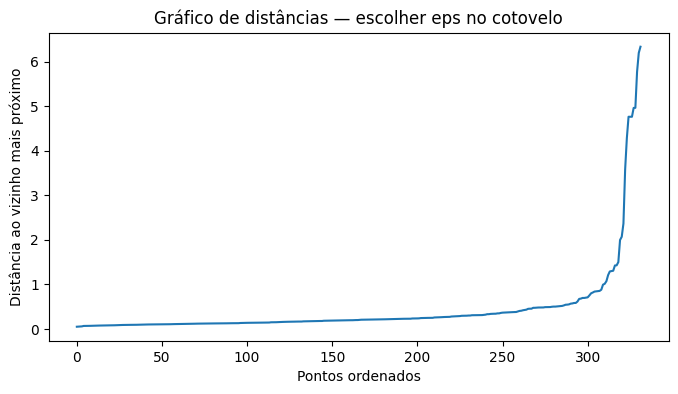

In [7]:
# gráfico de distâncias para escolher eps (zona do cotovelo)
# min_samples = nr features + 1 ou 2 x nr features (5 é default)
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X)
distances, _ = neighbors.kneighbors(X)
distances_sorted = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(distances_sorted)
plt.title('Gráfico de distâncias — escolher eps no cotovelo')
plt.xlabel('Pontos ordenados')
plt.ylabel('Distância ao vizinho mais próximo')
plt.show()

In [8]:
# através da análise do gráfico das distâncias escolheu-se eps=1
dbscan = DBSCAN(eps=1, min_samples=5)
df_cluster['cluster_dbscan'] = dbscan.fit_predict(X)

n_outliers = (df_cluster['cluster_dbscan'] == -1).sum()
print(f'Outliers identificados: {n_outliers} lojas ({n_outliers/len(df_cluster)*100:.1f}%)')

# perfil dos outliers para perceber o que os torna atípicos (baixa conversão e grande dispersão da rate)
df_cluster[df_cluster['cluster_dbscan'] == -1][features].describe().round(3)

Outliers identificados: 17 lojas (5.1%)


,sold_rate,profit_per_label,discount_avg
count,17.000,17.000,17.000
mean,0.370,0.094,0.365
std,0.366,0.106,0.135
min,0.000,0.000,0.100
25%,0.000,0.000,0.300
50%,0.300,0.043,0.363
75%,0.667,0.194,0.500
max,1.000,0.265,0.500


### 6. K-Means — restantes lojas

Remove outliers antes de correr o K para não distorcer os clusters.

   k  inertia  silhouette  menor_cluster
0  2  581.367       0.372            151
1  3  427.291       0.408             23
2  4  336.910       0.346             22
3  5  270.547       0.369             16
4  6  230.711       0.335             17
5  7  206.804       0.355             10
6  8  185.281       0.313             10


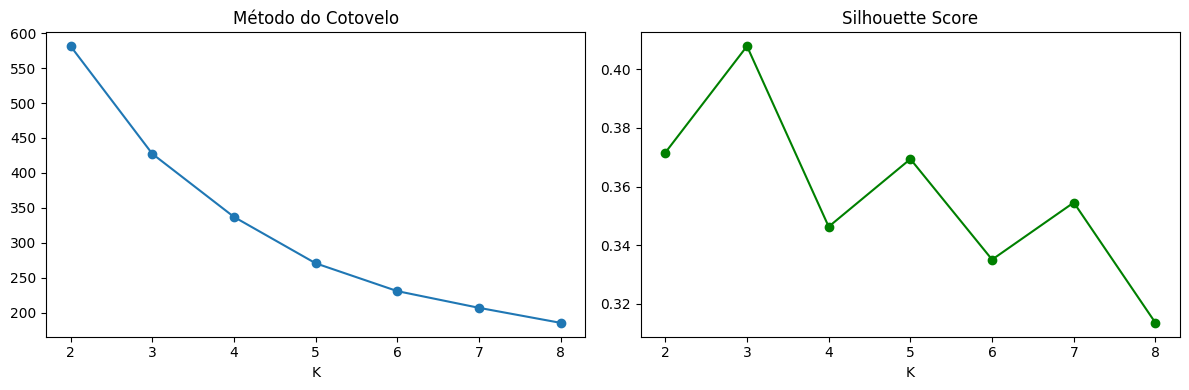

In [9]:
# separar lojas dos outliers
mask_others = df_cluster['cluster_dbscan'] != -1
X_others = scaler.fit_transform(df_cluster.loc[mask_others, features])

# testar K de 2 a 8
resultados_k = []
for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    clusters = modelo.fit_predict(X_others)
    resultados_k.append({
        'k':             k,
        'inertia':    modelo.inertia_,                              # soma das distâncias ao centróide (menor = mais compacto)
        'silhouette': silhouette_score(X_others, clusters),         # separação entre clusters (mais próximo de 1 = melhor)
        'menor_cluster': pd.Series(clusters).value_counts().min()   # tamanho do menor cluster
    })

df_k = pd.DataFrame(resultados_k)
print(df_k.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_k['k'], df_k['inertia'], marker='o')
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('K')
axes[1].plot(df_k['k'], df_k['silhouette'], marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
plt.tight_layout()
plt.show()

In [10]:
# aplicar K escolhido (mesmo reultado obtido da análise dos gráficos)
k_escolhido = int(df_k.loc[df_k['silhouette'].idxmax(), 'k'])
K = k_escolhido

# aplicar k-means
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df_cluster.loc[mask_others, 'cluster_kmeans'] = kmeans.fit_predict(X_others)

# outliers ficam com -1
df_cluster['cluster_kmeans'] = df_cluster['cluster_kmeans'].fillna(-1).astype(int)

print(f'K escolhido: {K}')
print(df_cluster['cluster_kmeans'].value_counts().sort_index())

K escolhido: 3
cluster_kmeans
-1     17
 0    142
 1    150
 2     23
Name: count, dtype: int64


### 7. Perfil dos clusters

In [11]:
# perfil com features do modelo e indicadores descritivos
cols_perfil = features + ['labels_per_uni_area', 'selling_square_ft', 'total_labels', 'sku_variety','perc_exp_avg']
perfil = df_cluster.groupby('cluster_kmeans')[cols_perfil].mean().round(3)
perfil['n_lojas']  = df_cluster.groupby('cluster_kmeans')['idstore'].count()
perfil['pct_lojas'] = (perfil['n_lojas'] / len(df_cluster) * 100).round(1)
perfil['dominant_type']     = df_cluster.groupby('cluster_kmeans')['type'].agg(lambda x: x.value_counts().index[0])
perfil['top_district']      = df_cluster.groupby('cluster_kmeans')['district'].agg(lambda x: x.value_counts().index[0])
perfil

,sold_rate,profit_per_label,discount_avg,labels_per_uni_area,selling_square_ft,total_labels,sku_variety,perc_exp_avg,n_lojas,pct_lojas,dominant_type,top_district
cluster_kmeans,,,,,,,,,,,,
-1,0.370,0.094,0.365,3.708,2430.824,23.824,3.941,0.116,17,5.1,Small,Guarda
0,0.607,0.102,0.303,60.227,5220.602,561.810,38.592,0.401,142,42.8,Medium,Lisboa
1,0.436,0.073,0.304,38.623,4742.267,413.553,36.260,0.349,150,45.2,Small,Porto
2,0.475,0.082,0.261,12.308,6766.348,339.478,33.478,0.340,23,6.9,Medium,Portalegre


In [12]:
# atribuir nomes aos clusters
nomes_clusters = {
    -1: 'Atípicas', # pior conversão e desconto maior
     0: 'Alta Conversão', # melhor conversão e lucro
     1: 'Risco de Desperdício', # pior lucro, pior conversão entre as típicas
     2: 'Conservadoras' # menor desconto e boa conversão

}

df_cluster['segment'] = df_cluster['cluster_kmeans'].map(nomes_clusters)
perfil.index = perfil.index.map(nomes_clusters)
perfil

,sold_rate,profit_per_label,discount_avg,labels_per_uni_area,selling_square_ft,total_labels,sku_variety,perc_exp_avg,n_lojas,pct_lojas,dominant_type,top_district
cluster_kmeans,,,,,,,,,,,,
Atípicas,0.370,0.094,0.365,3.708,2430.824,23.824,3.941,0.116,17,5.1,Small,Guarda
Alta Conversão,0.607,0.102,0.303,60.227,5220.602,561.810,38.592,0.401,142,42.8,Medium,Lisboa
Risco de Desperdício,0.436,0.073,0.304,38.623,4742.267,413.553,36.260,0.349,150,45.2,Small,Porto
Conservadoras,0.475,0.082,0.261,12.308,6766.348,339.478,33.478,0.340,23,6.9,Medium,Portalegre


| Cluster | Lojas | Característica principal |
|---------|-------|--------------------------|
| **Alta Conversão** | 142 (42.8%) | Vendem muito (taxa de venda - 60.7%), com boa margem (lucro por etiqueta - 0.10€). São um exemplo a seguir. |
| **Risco de Desperdício** | 150 (45.2%) | Muito volume de etiquetas (nr etiquetas médio - 414), mas vendem pouco (taxa de venda - 43.6%) e consequentemente margem reduzida (lucro por etiqueta - 0.07€). Estão a desperdiçar comida. |
| **Conservadoras** | 23 (6.9%) | Vendem razoavelmente bem (taxa de venda - 47.5%) sem precisar descontar tanto (desconto médio - 26.1%). |
| **Atípicas** | 17 (5.1%) | Emitem menos etiquetas (nr etiquetas médio - 23), fazem descontos elevados (desconto médio - 36.5%) que não estão a resultar em vendas (taxa de venda - 37.0%). |

### 8. Visualização

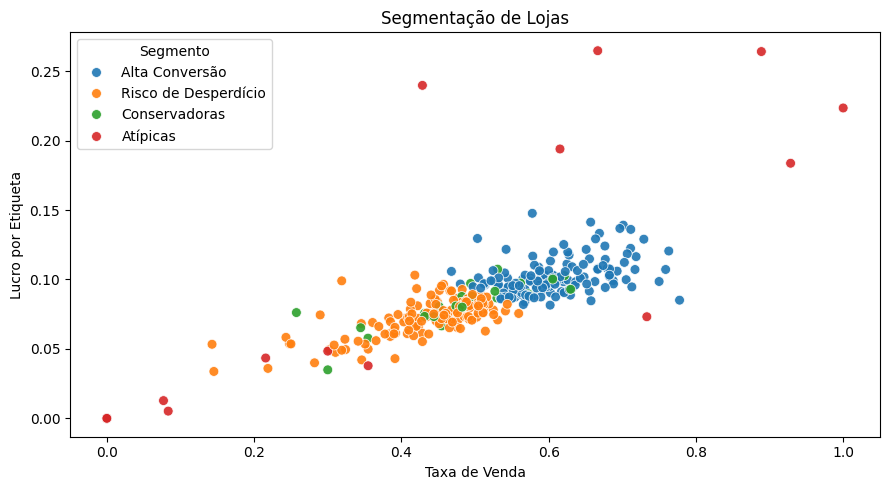

In [13]:
# scatter — taxa de venda vs lucro por etiqueta
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_cluster,
    x='sold_rate', y='profit_per_label',
    hue='segment', alpha=0.9, s=50
)
plt.title('Segmentação de Lojas')
plt.xlabel('Taxa de Venda')
plt.ylabel('Lucro por Etiqueta')
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()

# grande dispersão no segmento atipícas, lojas não partilham mesmo comportamento

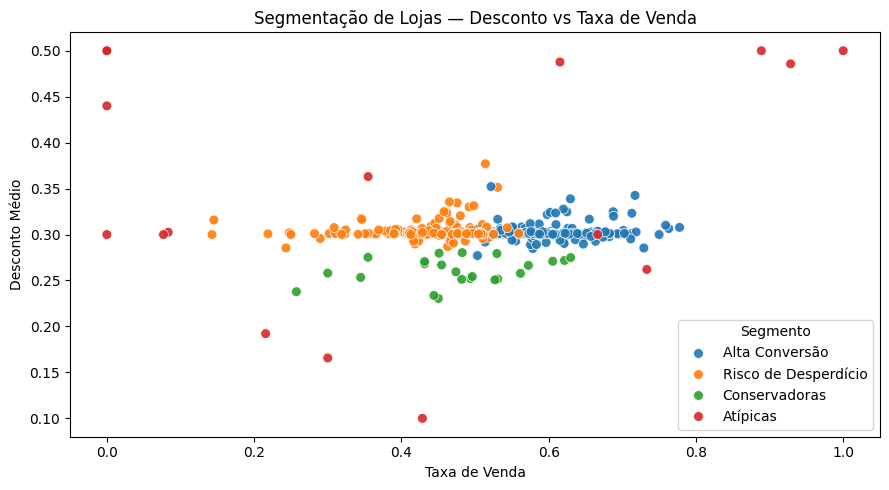

In [14]:
# scatter — taxa de venda vs avg desconto
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_cluster,
    x='sold_rate', y='discount_avg',
    hue='segment', alpha=0.9, s=50
)
plt.title('Segmentação de Lojas — Desconto vs Taxa de Venda')
plt.xlabel('Taxa de Venda')
plt.ylabel('Desconto Médio')
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()

In [15]:
df_cluster

,idstore,type,district,selling_square_ft,labels_per_uni_area,total_labels,sku_variety,perc_exp_avg,sold_rate,profit_per_label,discount_avg,cluster_dbscan,cluster_kmeans,segment
0,1,Large,Évora,4762.0,10.100798,481.0,21.0,0.446587,0.717256,0.107179,0.342578,0,0,Alta Conversão
1,2,Large,Bragança,12358.0,5.801910,717.0,59.0,0.374760,0.624826,0.111110,0.324714,0,0,Alta Conversão
2,3,Large,Lisboa,16159.0,2.165976,350.0,46.0,0.346032,0.457143,0.096513,0.301029,0,1,Risco de Desperdício
3,4,Large,Porto,17903.0,2.580573,462.0,64.0,0.196993,0.413420,0.067305,0.305130,0,1,Risco de Desperdício
4,5,Large,Coimbra,16179.0,7.367575,1192.0,74.0,0.363834,0.586409,0.108875,0.301619,0,0,Alta Conversão
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,328,Small,Guarda,115.0,6.956522,8.0,1.0,0.053030,0.000000,0.000000,0.500000,-1,-1,Atípicas
328,329,Small,Lisboa,1004.0,0.398406,4.0,1.0,0.333333,0.750000,0.098550,0.300000,0,0,Alta Conversão
329,330,Small,Leiria,3164.0,0.031606,1.0,1.0,0.200000,0.000000,0.000000,0.300000,-1,-1,Atípicas
330,331,Small,Guarda,215.0,1.395349,3.0,1.0,0.333333,0.666667,0.264733,0.300000,-1,-1,Atípicas


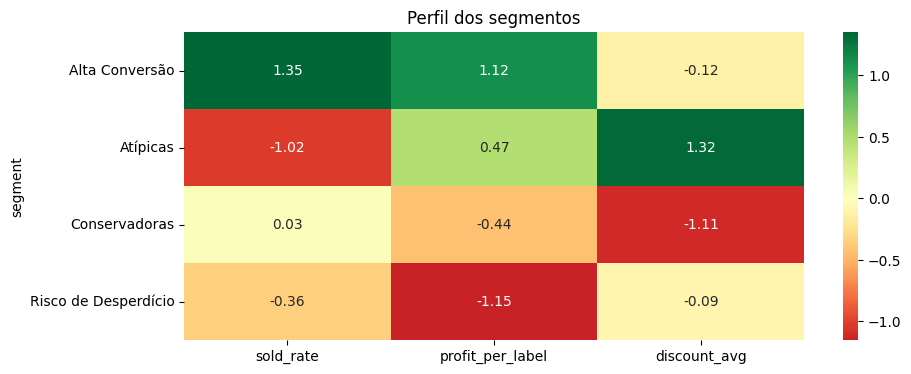

In [16]:
# heatmap do perfil dos segmentos
# normalização de cada feature para mostrar quanto cada segmento está acima ou abaixo da média de cada feature
perfil_viz = df_cluster.groupby('segment')[features].mean()
perfil_norm = (perfil_viz - perfil_viz.mean()) / perfil_viz.std()

plt.figure(figsize=(10, 4))
sns.heatmap(perfil_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Perfil dos segmentos')
plt.show()

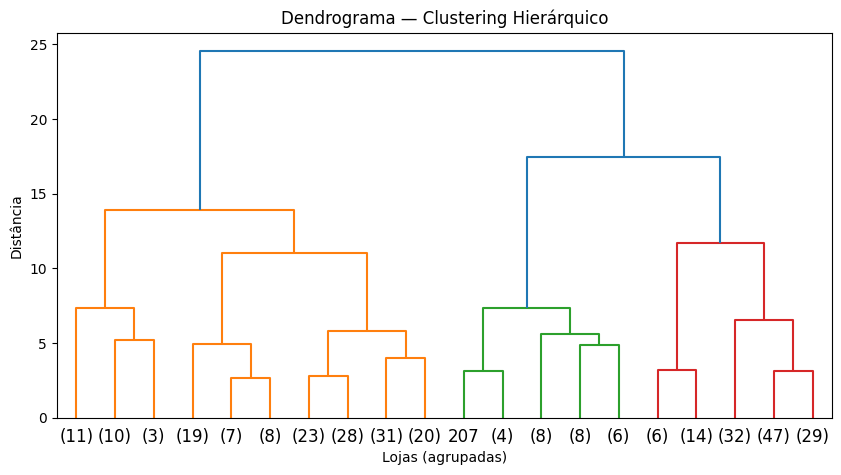

In [17]:
# dendograma, validação do k escolhido
Z = linkage(X_others, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Dendrograma — Clustering Hierárquico')
plt.xlabel('Lojas (agrupadas)')
plt.ylabel('Distância')
plt.show()

### 9. Exportar

In [18]:
# junta segmento/k-means ao dataframe das lojas
df = df.merge(df_cluster[['idstore', 'cluster_kmeans', 'segment']], on='idstore', how='left')
df['cluster_kmeans'] = df['cluster_kmeans'].astype('Int64')

df.to_excel('store_segmentation.xlsx', index=False)
print('Ficheiro guardado: store_segmentation.xlsx')

Ficheiro guardado: store_segmentation.xlsx


In [19]:
df

,idstore,type,selling_square_ft,district,area_missing_flag,total_labels,sold_labels,sold_rate,revenue_sold,profit_sold,margin_avg,discount_avg,days_to_sell_avg,sku_variety,card_share,perc_exp_avg,profit_per_label,labels_per_uni_area,cluster_kmeans,segment
0,1,Large,4762.0,Évora,0,481.0,345.0,0.717256,355.635,51.5531,15.024948,0.342578,1.069565,21.0,0.530435,0.446587,0.107179,10.100798,0,Alta Conversão
1,2,Large,12358.0,Bragança,0,717.0,448.0,0.624826,502.380,79.6660,15.711297,0.324714,1.120536,59.0,0.484375,0.374760,0.111110,5.801910,0,Alta Conversão
2,3,Large,16159.0,Lisboa,0,350.0,160.0,0.457143,199.210,33.7796,16.431429,0.301029,0.956250,46.0,0.537500,0.346032,0.096513,2.165976,1,Risco de Desperdício
3,4,Large,17903.0,Porto,0,462.0,191.0,0.413420,195.160,31.0950,16.562771,0.305130,1.010471,64.0,0.534031,0.196993,0.067305,2.580573,1,Risco de Desperdício
4,5,Large,16179.0,Coimbra,0,1192.0,699.0,0.586409,806.430,129.7791,15.844799,0.301619,0.793991,74.0,0.494993,0.363834,0.108875,7.367575,0,Alta Conversão
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,338,Small,1935.0,Leiria,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
338,339,Small,2680.0,Portalegre,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
339,340,Small,866.0,Coimbra,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
340,341,Small,936.0,Castelo Branco,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


### 10. Notas Finais

**Limitações**

- os dados refletem apenas outubro de 2021, o que não permite identificar padrões sazonais;
- não existem dados sobre o stock total para perceber se a loja faz uma boa gestão de stock ou se simplesmente se esquece de etiquetar;
- os clusters dependem das variáveis escolhidas para o modelo;
- a segmentação identifica padrões (correlação), mas não prova se uma coisa causou a outra (causalidade).

**Recomendações comerciais**

Alta Conversão

- como a taxa de conversão é boa, podemos testar reduzir um pouco os descontos.

Risco de Desperdício

- rever a seleção de produtos etiquetados;
- anticipar a etiquetagem face ao padrão habitual.

Conservadoras

- manter as práticas atuais mas ser mais agressivo no último dia de validade, colocando uma etiqueta com maior desconto. 

Atípicas

- como a média é de 23 etiquetas por mês, o impacto financeiro é reduzido. Manter uma auditoria básica para perceber o porquê de não aplicarem mais etiquetas.